# Crop Yield Forecasting (2023–2025)

Train on all historical data (1998–2022), then predict future yields using estimated rainfall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")
print(f"Loaded: {df.shape}")

Loaded: (19439, 23)


## 1. Configuration

Change the district and crop below to forecast for a different combination.

In [10]:
# ====== CHANGE THESE TO FORECAST DIFFERENT COMBOS ======
TARGET_DISTRICT = "ahilyanagar"
TARGET_CROP = "Soyabean"
FORECAST_YEARS = [2023, 2024, 2025]
# ========================================================

# Verify the combo exists
subset = df[(df['District'] == TARGET_DISTRICT) & (df['Crop'] == TARGET_CROP)]
print(f"Historical records for {TARGET_DISTRICT} + {TARGET_CROP}: {len(subset)}")
print(f"Years available: {sorted(subset['Year'].unique())}")
subset.tail()

Historical records for ahilyanagar + Soyabean: 27
Years available: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


,District,Year,Crop,Season,Area,Production,Yield,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,...,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
666,ahilyanagar,2020,Soyabean,Kharif,84480.32,141300.37,1.672583,0.570887,0.630973,0.958148,...,205.9,97.5,197.9,203.0,95.4,109.2,114.5,147.0,233.0,158.5
704,ahilyanagar,2021,Soyabean,Kharif,99300.03,157052.93,1.581600,1.672583,0.570887,1.275023,...,129.9,97.5,121.8,124.9,95.4,112.5,118.0,147.0,190.5,129.6
705,ahilyanagar,2021,Soyabean,Summer,3195.00,4792.50,1.500000,1.500000,1.500000,1.500000,...,129.9,97.5,121.8,124.9,95.4,112.5,118.0,147.0,190.5,129.6
741,ahilyanagar,2022,Soyabean,Kharif,110629.00,200692.00,1.814099,1.581600,1.672583,1.689428,...,105.0,97.5,121.2,124.3,95.4,109.0,114.3,147.0,233.4,158.8
742,ahilyanagar,2022,Soyabean,Summer,1475.00,2212.50,1.500000,1.500000,1.500000,1.500000,...,105.0,97.5,121.2,124.3,95.4,109.0,114.3,147.0,233.4,158.8


## 2. Train Model on All Data

In [11]:
X = df.drop(columns=["Yield", "Production", "Area"])
y = df["Yield"]

label_encoders = {}
for col in ["District", "Crop", "Season"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X, y)

print(f"Model trained on {len(X)} samples")
print(f"OOB-like R² (train): {model.score(X, y):.4f}")

Model trained on 19439 samples
OOB-like R² (train): 0.9741


## 3. Build Future Input Rows

For future years, we use:
- **Rainfall**: district's long-term normal values
- **Lag features**: computed from the last known years (2020–2022)

In [12]:
# Get the district's normal rainfall (same across years)
district_data = df[df['District'] == TARGET_DISTRICT]
rainfall_normals = district_data.iloc[0][['june_normal_rainfall','july_normal_rainfall','august_normal_rainfall','september_normal_rainfall']]

# Get the most common season for this crop in this district
crop_data = district_data[district_data['Crop'] == TARGET_CROP]
main_season = crop_data['Season'].mode().iloc[0]

# Get recent yields for lag computation
recent = crop_data.sort_values('Year').tail(3)
recent_yields = recent['Yield'].values

print(f"Normal rainfall: {dict(rainfall_normals)}")
print(f"Season: {main_season}")
print(f"Recent yields (last 3 years): {recent_yields}")

Normal rainfall: {'june_normal_rainfall': np.float64(108.2), 'july_normal_rainfall': np.float64(97.5), 'august_normal_rainfall': np.float64(95.4), 'september_normal_rainfall': np.float64(147.0)}
Season: Kharif
Recent yields (last 3 years): [1.5        1.81409938 1.5       ]


In [13]:
future_rows = []

for i, year in enumerate(FORECAST_YEARS):
    row = {
        'District': TARGET_DISTRICT,
        'Year': year,
        'Crop': TARGET_CROP,
        'Season': main_season,
        'Yield_Lag1': recent_yields[-1] if i == 0 else future_rows[-1].get('predicted_yield', recent_yields[-1]),
        'Yield_Lag2': recent_yields[-2] if i == 0 else (recent_yields[-1] if i == 1 else future_rows[-2].get('predicted_yield', recent_yields[-2])),
        'Yield_3yr_Avg': np.mean(recent_yields) if i == 0 else np.mean([r.get('predicted_yield', 0) for r in future_rows[-2:]] + [recent_yields[-1]]),
        'Yield_3yr_Std': np.std(recent_yields) if i == 0 else np.std([r.get('predicted_yield', 0) for r in future_rows[-2:]] + [recent_yields[-1]]),
        'june_normal_rainfall': rainfall_normals['june_normal_rainfall'],
        'june_actual_rainfall': rainfall_normals['june_normal_rainfall'],  # use normal as estimate
        'june_percent_to_normal': 100.0,
        'july_normal_rainfall': rainfall_normals['july_normal_rainfall'],
        'july_actual_rainfall': rainfall_normals['july_normal_rainfall'],
        'july_percent_to_normal': 100.0,
        'august_normal_rainfall': rainfall_normals['august_normal_rainfall'],
        'august_actual_rainfall': rainfall_normals['august_normal_rainfall'],
        'august_percent_to_normal': 100.0,
        'september_normal_rainfall': rainfall_normals['september_normal_rainfall'],
        'september_actual_rainfall': rainfall_normals['september_normal_rainfall'],
        'september_percent_to_normal': 100.0,
    }
    
    # Encode and predict
    row_df = pd.DataFrame([row])
    for col in ["District", "Crop", "Season"]:
        row_df[col] = label_encoders[col].transform(row_df[col])
    
    feature_cols = X.columns
    pred = model.predict(row_df[feature_cols])[0]
    row['predicted_yield'] = pred
    future_rows.append(row)
    print(f"{year}: Predicted Yield = {pred:.4f}")

2023: Predicted Yield = 1.5678
2024: Predicted Yield = 1.5286
2025: Predicted Yield = 1.5267


## 4. Visualize: Historical + Forecasted Yield

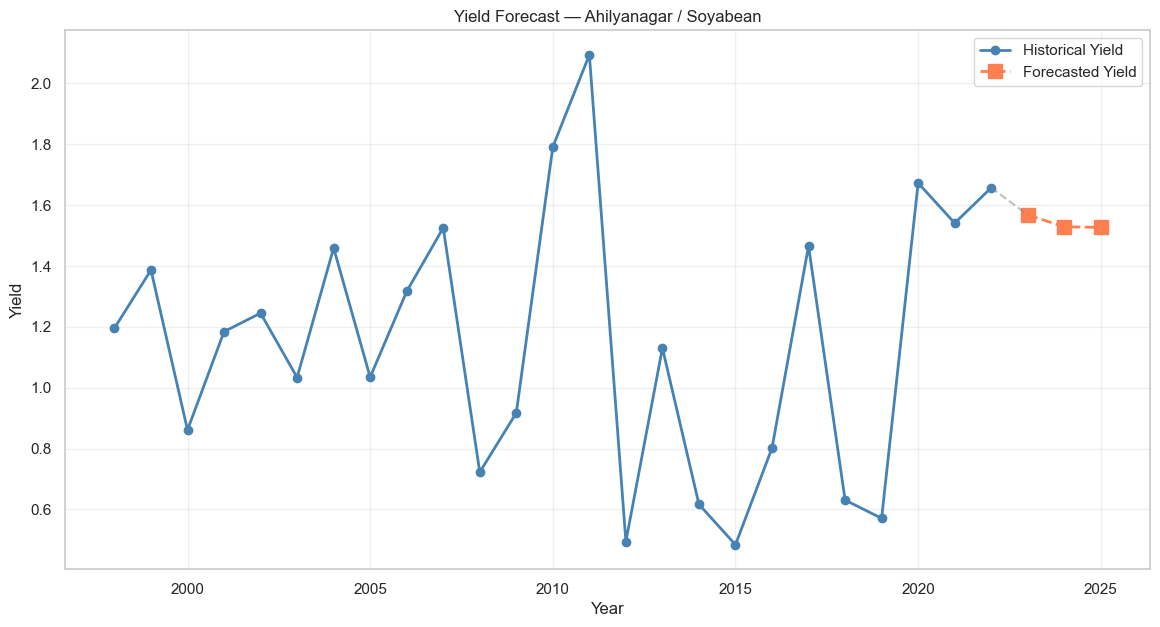

In [14]:
historical = crop_data.groupby('Year')['Yield'].mean().reset_index()

plt.figure(figsize=(14, 7))
plt.plot(historical['Year'], historical['Yield'], 'o-', color='steelblue', linewidth=2, label='Historical Yield')
plt.plot(FORECAST_YEARS, [r['predicted_yield'] for r in future_rows], 's--', color='coral', linewidth=2, markersize=10, label='Forecasted Yield')

# Connect historical to forecast
plt.plot([historical['Year'].iloc[-1], FORECAST_YEARS[0]], 
         [historical['Yield'].iloc[-1], future_rows[0]['predicted_yield']], 
         '--', color='gray', alpha=0.5)

plt.title(f'Yield Forecast — {TARGET_DISTRICT.title()} / {TARGET_CROP}')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Scenario Analysis — What If Rainfall Changes?

Drought (-30%)      : Yield = 1.5595
Normal              : Yield = 1.5678
Excess (+30%)       : Yield = 1.5762


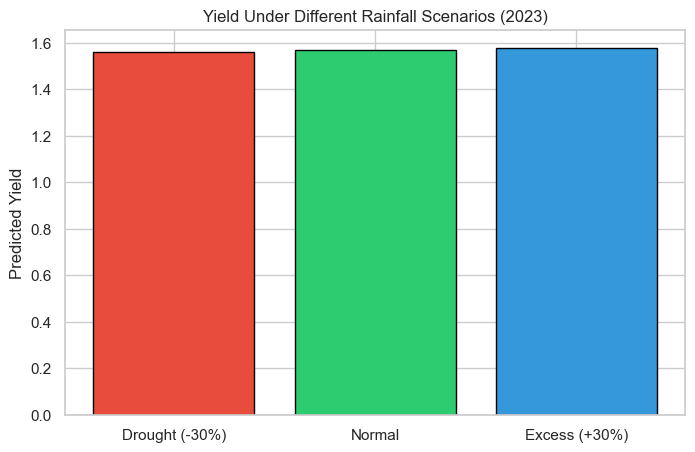

In [15]:
scenarios = {'Drought (-30%)': 0.7, 'Normal': 1.0, 'Excess (+30%)': 1.3}
scenario_results = {}

for scenario_name, multiplier in scenarios.items():
    row = future_rows[0].copy()
    row_df = pd.DataFrame([row])
    
    # Adjust actual rainfall columns
    for month in ['june', 'july', 'august', 'september']:
        col = f'{month}_actual_rainfall'
        row_df[col] = row_df[f'{month}_normal_rainfall'] * multiplier
        row_df[f'{month}_percent_to_normal'] = multiplier * 100
    
    for col in ["District", "Crop", "Season"]:
        row_df[col] = label_encoders[col].transform(row_df[col])
    
    pred = model.predict(row_df[X.columns])[0]
    scenario_results[scenario_name] = pred
    print(f"{scenario_name:20s}: Yield = {pred:.4f}")

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
plt.bar(scenario_results.keys(), scenario_results.values(), color=colors, edgecolor='black')
plt.title(f'Yield Under Different Rainfall Scenarios ({FORECAST_YEARS[0]})')
plt.ylabel('Predicted Yield')
plt.show()

## 6. Forecast Summary Table

In [16]:
summary = pd.DataFrame(future_rows)[['Year', 'District', 'Crop', 'Season', 'predicted_yield']]
summary.columns = ['Year', 'District', 'Crop', 'Season', 'Predicted Yield']
print(summary.to_string(index=False))

 Year    District     Crop Season  Predicted Yield
 2023 ahilyanagar Soyabean Kharif         1.567760
 2024 ahilyanagar Soyabean Kharif         1.528599
 2025 ahilyanagar Soyabean Kharif         1.526704
